In [ ]:
import slangpy as spy
from pyglm import glm
import matplotlib.pyplot as plt
import numpy as np
import quaternion
from PIL import Image
import pathlib
import jax
import jax.numpy as jnp


from bvhgs import device
from bvhgs.camera import Camera
from bvhgs.gaussian import GaussianCloud
from bvhgs.renderer import Renderer
from bvhgs.prefix_sum import prefix_sum
from bvhgs.radix_sort import radix_sort

In [2]:
np.random.seed(0)

# Load Gaussian Buffer

In [3]:
gaussians = GaussianCloud()
gaussians.load_from_colmap(pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"), scale_factor=-4)
len(gaussians)

NameError: name 'pycolmap' is not defined

# Load Module and Shader

In [ ]:
module = device.load_module("renderer.slang")
module

SlangModule(
  name = renderer.slang,
  path = D:\Projects\bvhgs\src\bvhgs\slang\renderer.slang,
  entry_points = [
    SlangEntryPoint(name="project", stage=compute),
    SlangEntryPoint(name="cull", stage=compute),
    SlangEntryPoint(name="bwdCullProjection", stage=compute),
    SlangEntryPoint(name="computeTile", stage=compute),
    SlangEntryPoint(name="buildGaussianTable", stage=compute),
    SlangEntryPoint(name="tileHistogram", stage=compute),
    SlangEntryPoint(name="duplicateGaussian", stage=compute),
    SlangEntryPoint(name="rasterize", stage=compute),
    SlangEntryPoint(name="bwdDuplicateGaussian", stage=compute),
    SlangEntryPoint(name="bwdRasterize", stage=compute),
    SlangEntryPoint(name="extractSortedGaussianGrad", stage=compute),
    SlangEntryPoint(name="gradDescentGaussian2D", stage=compute),
  ]
)

In [ ]:
program = device.link_program([module], [])
program

ShaderProgram(
  modules = [
    SlangModule(
      name = renderer.slang,
      path = D:\Projects\bvhgs\src\bvhgs\slang\renderer.slang,
      entry_points = [
        SlangEntryPoint(name="project", stage=compute),
        SlangEntryPoint(name="cull", stage=compute),
        SlangEntryPoint(name="bwdCullProjection", stage=compute),
        SlangEntryPoint(name="computeTile", stage=compute),
        SlangEntryPoint(name="buildGaussianTable", stage=compute),
        SlangEntryPoint(name="tileHistogram", stage=compute),
        SlangEntryPoint(name="duplicateGaussian", stage=compute),
        SlangEntryPoint(name="rasterize", stage=compute),
        SlangEntryPoint(name="bwdDuplicateGaussian", stage=compute),
        SlangEntryPoint(name="bwdRasterize", stage=compute),
        SlangEntryPoint(name="extractSortedGaussianGrad", stage=compute),
        SlangEntryPoint(name="gradDescentGaussian2D", stage=compute),
      ]
    ),
  ],
  entry_points = []
)

# Build Slang Buffer and Camera Parameter

In [ ]:
# Create a buffer for the Gaussian points.
gaussian_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_3d,
    usage=spy.BufferUsage.shader_resource,
)
# Store all the gaussian points in the buffer.
gaussian_cursor = spy.BufferCursor(
    program.reflection.g_gaussian_3d.type_layout.element_type_layout,
    gaussian_buf,
)

for i in range(len(gaussians)):
    gaussian_cursor[i].write(gaussians[i])
gaussian_cursor.apply()

In [ ]:
sfm_dataset = SFMDataset()
sfm_dataset.load_from_colmap(
    colmap_path=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"),
    image_dir=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/images/")
)

{'_rotation': [-0.03458227962255478, 0.32694852352142334, 0.0032672483939677477, 0.9444036483764648], '_translation': vec3( -1.23324, -0.470908, 3.94508 ), '_sensorSize': uvec2( 979, 546 ), '_focalLength': 581.9245354745742, '_nearPlane': 0.1, '_farPlane': 1000.0}


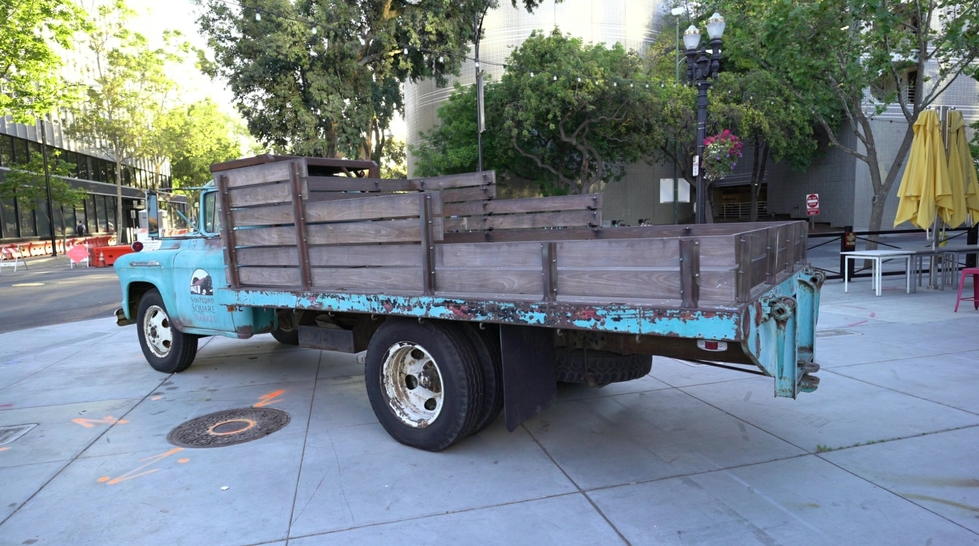

In [ ]:
camera, image_path = sfm_dataset[0]
print(camera.to_slang())
image = Image.open(image_path)
image

# Projection

## Dispatch Projection Kernel

In [ ]:
# Create a buffer for the Gaussian2D points.
gaussian2d_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_2d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian2d_buf

Buffer(
  device = 0x19334450538,
  size = 6281520,
  struct_size = 60,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 5.99 MB,
  label = 
)

In [ ]:
# Create flag buffer for culling.
inside_flag_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_inside_flag,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
inside_flag_buf

Buffer(
  device = 0x19334450538,
  size = 418768,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 408.95 kB,
  label = 
)

In [ ]:
ker_proj = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("project")])
)
ker_proj

ComputeKernel(0x19344b76f80)

In [ ]:
ker_proj.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_gaussian_3d": gaussian_buf,
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf
    }
)

In [ ]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d.type_layout.element_type_layout,
    gaussian2d_buf,
)
cursor.element_count
cursor[0]

{'position': {0.237611, 0.5327741, 0.0039648735}, 'covariance': {{7.174687e-06, 5.562653e-15}, {-1.5483537e-14, 2.3066566e-05}}, 'color': {0.488279, 0.5273407, 0.60937047}, 'opacity': 0.5, 'cachedInvCov': {{139378.9, -3.361213e-05}, {9.3558716e-05, 43352.79}}} [Gaussian2D]

## Cull Gaussians

In [ ]:
ker_cull = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("cull")])
)

In [ ]:
# Cull the Gaussian points.
inside_offset_buf = prefix_sum(inside_flag_buf)
inside_offset_cursor = spy.BufferCursor(
    program.reflection.g_inside_offset.type_layout.element_type_layout,
    inside_offset_buf,
)
# Read the last element of the cull prefix buffer to get the number of culled points.
num_viewing = int(inside_offset_cursor[len(inside_offset_cursor) - 1].read())  # type: ignore
num_viewing

93477

In [ ]:
# Culled gaussians
culled_gaussian_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
culled_gaussian_buf

Buffer(
  device = 0x19334450538,
  size = 5608620,
  struct_size = 60,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 5.35 MB,
  label = 
)

In [ ]:
ker_cull.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf,
        "g_inside_offset": inside_offset_buf,
        "g_gaussian_2d_culled": culled_gaussian_buf
    }
)

In [ ]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d_culled.type_layout.element_type_layout,
    culled_gaussian_buf,
)
cursor[0]

{'position': {0.237611, 0.5327741, 0.0039648735}, 'covariance': {{7.174687e-06, 5.562653e-15}, {-1.5483537e-14, 2.3066566e-05}}, 'color': {0.488279, 0.5273407, 0.60937047}, 'opacity': 0.5, 'cachedInvCov': {{139378.9, -3.361213e-05}, {9.3558716e-05, 43352.79}}} [Gaussian2D]

# Tiling

In [ ]:
ker_tile = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("computeTile")])
)
ker_build_gs = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("buildGaussianTable")])
)

In [ ]:
num_tile_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_num_tiles,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
num_tile_buf

Buffer(
  device = 0x19334450538,
  size = 373908,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 365.14 kB,
  label = 
)

In [ ]:
ker_tile.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles": num_tile_buf
    }
)

In [ ]:
num_tile_arr = num_tile_buf.to_numpy().view(np.uint32)
num_table_entries = np.sum(num_tile_arr).item()
num_table_entries

206226

In [ ]:
gaussian_table_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_table,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_table_buf

Buffer(
  device = 0x19334450538,
  size = 3299616,
  struct_size = 16,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 3.15 MB,
  label = 
)

In [ ]:
num_tile_prefix_buf = prefix_sum(num_tile_buf)

In [ ]:
ker_build_gs.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles_prefix": num_tile_prefix_buf,
        "g_gaussian_table": gaussian_table_buf,
    }
)

# Sort Tile

In [ ]:
numpy_sort(gaussian_table_buf)

In [ ]:
ker_tile_hist = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("tileHistogram")])
)

In [ ]:
hist_buf = device.create_buffer(
    element_count=2**8,
    struct_type=program.reflection.g_tile_hist_atomic,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)
# Compute the histogram of the Gaussian table.
ker_tile_hist.dispatch(
    thread_count=[num_table_entries, 1, 1],
    numEntries=num_table_entries,
    vars={
        "g_gaussian_table": gaussian_table_buf,
        "g_tile_hist_atomic": hist_buf,
    },
)

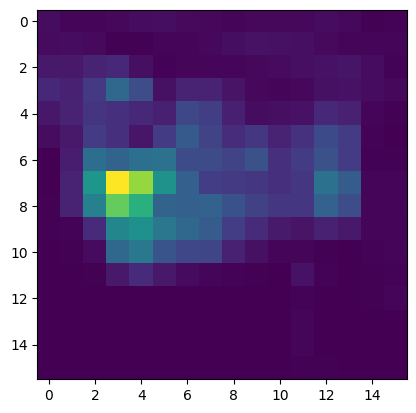

In [ ]:
plt.imshow(hist_buf.to_numpy().view(np.uint32).reshape(16, 16))

# Rasterize

In [ ]:
ker_duplicate = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("duplicateGaussian")])
)
ker_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("rasterize")])
)

In [ ]:
gaussian_2d_sorted_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_2d_sorted_buf

Buffer(
  device = 0x19334450538,
  size = 12373560,
  struct_size = 60,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 11.80 MB,
  label = 
)

In [ ]:
ker_duplicate.dispatch(
    thread_count=[num_table_entries, 1, 1],
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_gaussian_table": gaussian_table_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf
    }
)

In [ ]:
render_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

depth_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

num_depth_buf = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_uint,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [ ]:
hist_arr = hist_buf.to_numpy().view(np.uint32)
hist_offs = np.zeros_like(hist_arr)
hist_offs[1:] = np.cumsum(hist_arr)[:-1]

In [ ]:
tile_offst_buf = device.create_buffer(
    element_count=len(hist_offs),
    struct_type=program.reflection.g_tile_offs,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
tile_offst_buf.copy_from_numpy(hist_offs)

In [ ]:
ker_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target,
        "g_depth_target": depth_target,
        "g_num_rendered_gaussians": num_depth_buf,
    }
)

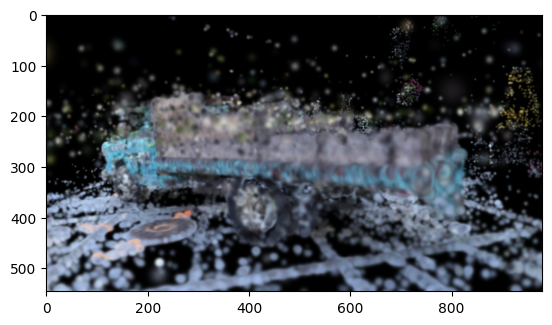

In [ ]:
raw_image = jnp.array(render_target.to_numpy()[:, :, :3])
plt.imshow(raw_image)

# Image Loss

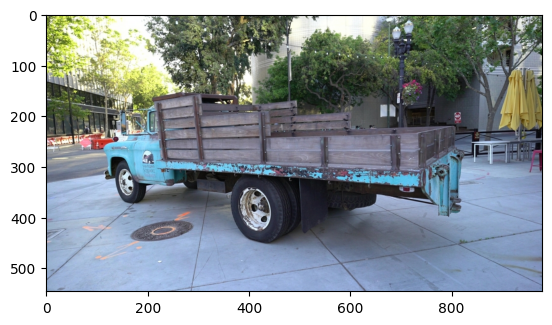

In [ ]:
image_arr = jnp.array(image).astype(jnp.float32) / 255.0
plt.imshow(image_arr)

In [ ]:
def image_loss(src: jnp.ndarray, dst: jnp.ndarray):
    return jnp.mean((dst - src)**2)

In [ ]:
image_loss(raw_image, image_arr)

Array(0.1578716, dtype=float32)

In [ ]:
# Image grad.
loss_grad = jax.value_and_grad(image_loss)

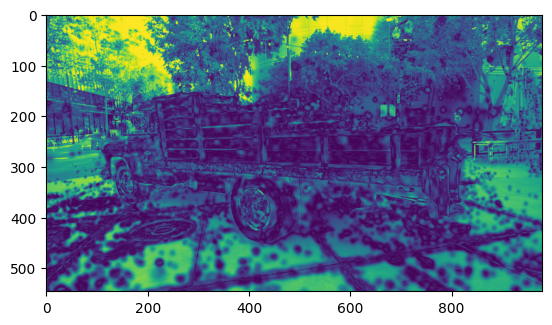

In [ ]:
loss, render_target_grad = loss_grad(raw_image, image_arr)
plt.imshow(jnp.linalg.norm(render_target_grad, axis=-1))

In [ ]:
render_target_grad.shape

(546, 979, 3)

In [ ]:
rg_shape = render_target_grad.shape
render_target_grad = jnp.concatenate((render_target_grad, jnp.zeros((rg_shape[0], rg_shape[1], 1))), axis=-1)
render_target_grad.shape

(546, 979, 4)

# Backward Gradient into Slang

In [ ]:
ker_bwd_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("bwdRasterize")])
)
ker_grad_descent = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("gradDescentGaussian2D")])
)

In [ ]:
grad_texture = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [ ]:
grad_texture.copy_from_numpy(render_target_grad)

In [ ]:
a_gaussian_2d_sorted_grad_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.d_a_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)
gaussian_2d_sorted_grad_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.d_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)

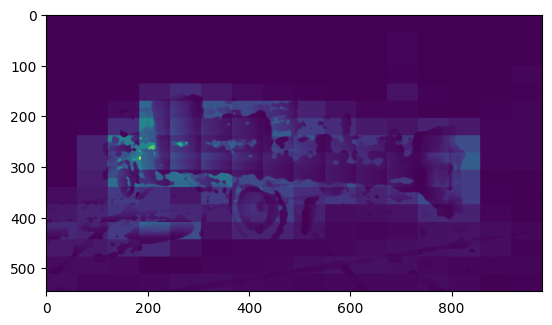

In [ ]:
num_depth_buf.to_numpy().view(np.uint32)
plt.imshow(num_depth_buf.to_numpy().view(np.uint32))

In [ ]:
ker_bwd_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target,
        "g_num_rendered_gaussians": num_depth_buf,
        "d_render_target": grad_texture,
        "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
        
    }
)

In [ ]:
ker_grad_descent.dispatch(
    thread_count=[num_table_entries, 1, 1],
    lr=1e-2,
    vars={
        "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
        
    }
)

## A Very Simple Gradient Descent

In [ ]:
num_epoch = 64
lr = 10


for epoch in range(num_epoch):
    print(f"Epoch {epoch + 1}/{num_epoch}")

    ker_rasterize.dispatch(
        thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
        vars={
            "g_camera": camera.to_slang(),
            "g_tile_hist": hist_buf,
            "g_tile_offs": tile_offst_buf,
            "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
            "g_render_target": render_target,
            "g_depth_target": depth_target,
            "g_num_rendered_gaussians": num_depth_buf,
        }
    )
    raw_image = jnp.array(render_target.to_numpy()[:, :, :3])
    loss, render_target_grad = loss_grad(raw_image, image_arr)

    print(f"Loss after gradient descent: {loss}")

    rg_shape = render_target_grad.shape
    render_target_grad = jnp.concatenate((render_target_grad, jnp.zeros((rg_shape[0], rg_shape[1], 1))), axis=-1)
    
    a_gaussian_2d_sorted_grad_buf.copy_from_numpy(
        np.zeros((a_gaussian_2d_sorted_grad_buf.size,), dtype=np.uint8))
    
    grad_texture.copy_from_numpy(render_target_grad)
    
    ker_bwd_rasterize.dispatch(
        thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
        vars={
            "g_camera": camera.to_slang(),
            "g_tile_hist": hist_buf,
            "g_tile_offs": tile_offst_buf,
            "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
            "g_render_target": render_target,
            "d_render_target": grad_texture,
            "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
            "g_num_rendered_gaussians": num_depth_buf,
        }
    )
    
    ker_grad_descent.dispatch(
        thread_count=[num_table_entries, 1, 1],
        lr=lr,
        vars={
            "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
            "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        }
    )
    
    gd = a_gaussian_2d_sorted_grad_buf.to_numpy().view(np.float32)
    print(f"Max gradient: {np.max(gd)}", f"Min gradient: {np.min(gd)}")


Epoch 1/64
Loss after gradient descent: 0.10218490660190582
Max gradient: 0.0039686341769993305 Min gradient: -0.001215628464706242
Epoch 2/64
Loss after gradient descent: 0.10211937129497528
Max gradient: 0.0020157210528850555 Min gradient: -0.0035084339324384928
Epoch 3/64
Loss after gradient descent: 0.10219266265630722
Max gradient: 0.00171463075093925 Min gradient: -0.0027397165540605783
Epoch 4/64
Loss after gradient descent: 0.10280396789312363
Max gradient: 0.00849150400608778 Min gradient: -0.0048640696331858635
Epoch 5/64
Loss after gradient descent: 0.10383251309394836
Max gradient: 0.0067702485248446465 Min gradient: -0.0038504295516759157
Epoch 6/64
Loss after gradient descent: 0.10580652207136154
Max gradient: 0.006185499485582113 Min gradient: -0.010607591830193996
Epoch 7/64
Loss after gradient descent: 0.1059962585568428
Max gradient: 0.014770363457500935 Min gradient: -0.02222609333693981
Epoch 8/64
Loss after gradient descent: 0.10743258148431778
Max gradient: 0.0116

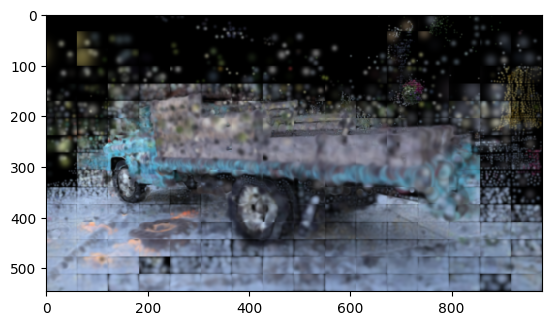

In [ ]:
plt.imshow(raw_image)

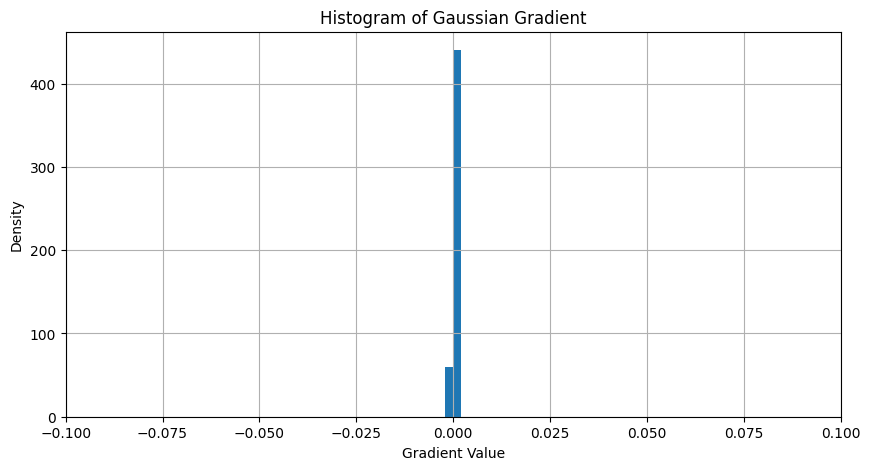

In [ ]:
import matplotlib.pyplot as plt

#histogram of gd
plt.figure(figsize=(10, 5))
plt.hist(gd, bins=100, range=(-0.1, 0.1), density=True)
plt.title("Histogram of Gaussian Gradient")
plt.xlabel("Gradient Value")
plt.ylabel("Density")
plt.xlim(-0.1, 0.1)
plt.grid()
plt.show()


In [ ]:
a_gaussian_2d_sorted_grad_buf.size

9073944